# Notebook 7: Euler Sampling with SMC-Ctrk and Factor Decomposition

This notebook applies SMC-Ctrl together with Euler sampling for conditional generation with a factor decomposition of the target distribution.


### Conclusion

- No significant difference was observed when adding SMC-Ctrl in this factorized Euler setting.
- The main visible effect only appeared at very high guidance scale (200), where relatively high $\lambda$ and $k$ resulted in a slighlty more diverse generation.


In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from acg import get_sigmas_karras, sample_heun, sample_euler, ExactDenoiser
from acg.datasets import make_half_helix, make_gaussian_mixture

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:

class FactorGraphDenoiserSMCCondC_Y:
    def __init__(
        self,
        denoiser_xy,
        denoiser_yc,
        denoiser_y,
        c_fixed,
        guidance_scale=10.0,
        smc_lambda=2.0,
        smc_k=0.001,
        use_smc=True,
    ):
        self.denoiser_xy = denoiser_xy
        self.denoiser_yc = denoiser_yc
        self.denoiser_y = denoiser_y
        self.c_fixed = c_fixed

        self.guidance_scale = guidance_scale
        self.smc_lambda = smc_lambda
        self.smc_k = smc_k
        self.use_smc = use_smc

        self.e_prev = None

    def reset(self):
        self.e_prev = None

    def _sigma_sq(self, sigma, x_full):
        if sigma.ndim == 0:
            return sigma**2
        return sigma.view(-1, 1) ** 2

    def _split_scores(self, x_full: torch.Tensor, sigma: torch.Tensor):
        sigma_sq = self._sigma_sq(sigma, x_full)

        x = x_full[:, 0:1]
        y = x_full[:, 1:2]
        c = torch.full_like(y, self.c_fixed)

        xy = torch.cat([x, y], dim=1)
        yc = torch.cat([y, c], dim=1)

        D_xy = self.denoiser_xy(xy, sigma)   # [B, 2]
        D_yc = self.denoiser_yc(yc, sigma)   # [B, 2]
        D_y  = self.denoiser_y(y, sigma)     # [B, 1]

        s_xy = (D_xy - xy) / sigma_sq
        s_yc = (D_yc - yc) / sigma_sq
        s_y  = (D_y  - y)  / sigma_sq

        return s_xy, s_yc, s_y, sigma_sq

    def __call__(self, x_full: torch.Tensor, sigma: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the SMC-guided denoised prediction for p(x, y | c_fixed).
        This class is stateful because SMC uses the previous error e_prev.
        """
        s_xy, s_yc, s_y, sigma_sq = self._split_scores(x_full, sigma)

        # Unconditional score: p(x, y)
        s_unc = torch.zeros_like(x_full)
        s_unc[:, 0:1] = s_xy[:, 0:1]
        s_unc[:, 1:2] = s_xy[:, 1:2]

        # Raw conditional correction = score of p(c | y)
        e_t = torch.zeros_like(x_full)
        e_t[:, 1:2] = s_yc[:, 0:1] - s_y

        if self.use_smc:
            if self.e_prev is None:
                self.e_prev = e_t

            s_slide = (e_t - self.e_prev) + self.smc_lambda * self.e_prev
            delta_e = -self.smc_k * torch.sign(s_slide)
            e_hat = e_t + delta_e

            self.e_prev = e_hat.detach()
        else:
            e_hat = e_t
            self.e_prev = e_hat.detach()

        s_guided = s_unc + self.guidance_scale * e_hat

        D_full = x_full + sigma_sq * s_guided
        return D_full

## 1. Create target distribution

In [4]:

# --------------------------
# 1) Generate dataset
# --------------------------
N = 20000 
x, y, c = make_half_helix(n_samples=N)

print("Shapes:", x.shape, y.shape, c.shape)

Shapes: torch.Size([20000]) torch.Size([20000]) torch.Size([20000])


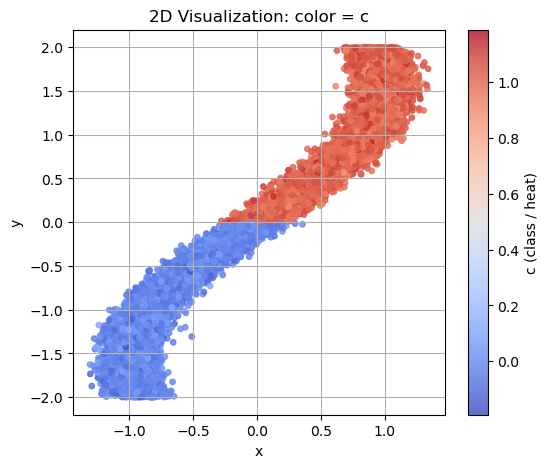

In [5]:

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    x, y,
    c=c,
    cmap="coolwarm",   # nice for binary-like values
    s=15,
    alpha=0.8
)

plt.colorbar(sc, label="c (class / heat)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Visualization: color = c")
plt.grid(True)

plt.show()

In [6]:
# Append color and coords
data = torch.stack([x, y, c], dim=1)

# shape: (N, 3) → (x, y, c)

## 2. Conditional generation (with  graph decomposition) + SMC-CFG

### 2.1 Initial data

In [9]:
# Fixed value for c
C = 1.0

# Pair datasets
data_xy = data[:, [0, 1]]  # (x, y)
data_yc = data[:, [1, 2]]  # (y, c)
data_y  = data[:, [1]]     # y only

# Create denoisers for each 
denoiser_xy = ExactDenoiser(data=data_xy)
denoiser_yc = ExactDenoiser(data=data_yc)
denoiser_y = ExactDenoiser(data=data_y)

print(f"Conditional denoisers created")

# Noise schedule
# Karras noise schedule
n_steps = 100
sigma_min = 0.01
sigma_max = 2.0

sigmas = get_sigmas_karras(
    n_steps=n_steps,
    sigma_min=sigma_min,
    sigma_max=sigma_max,
    device=device
)

# Scale initial samples
n_samples = 20
latents = torch.randn(n_samples, 2, device=device) * sigmas[0]

print(f"Noise schedule: {n_steps} steps, sigma=[{sigma_min}, {sigma_max}]")

# Wrap them
factor_denoiser = FactorGraphDenoiserSMCCondC_Y(
    denoiser_xy=denoiser_xy,
    denoiser_yc=denoiser_yc,
    denoiser_y=denoiser_y,
    c_fixed = C,
    guidance_scale=10,
    smc_lambda=2.0,
    smc_k=0.001,
    use_smc=True,

)

# Sample
traj = sample_euler(
    denoiser=factor_denoiser,
    latents=latents.clone(),   # [B,2]
    sigmas=sigmas,
    return_trajectory=True
)

print(traj.shape)

# Reset denoiser for next sampling
factor_denoiser.reset()

# Add c
traj= torch.cat([traj, torch.full_like(traj[..., :1], C)], dim=2)

Conditional denoisers created
Noise schedule: 100 steps, sigma=[0.01, 2.0]
torch.Size([20, 101, 2])


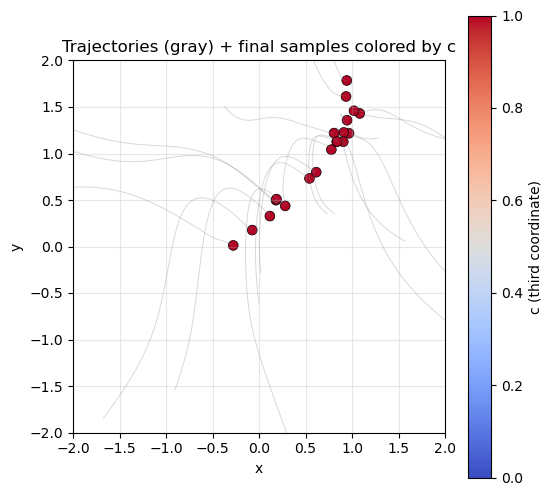

In [10]:


traj_np = traj.cpu().numpy()  # (N, T, 3)

plt.figure(figsize=(6, 6))

# 1. Plot trajectories in gray (only x,y)
for i in range(traj_np.shape[0]):
    plt.plot(
        traj_np[i, :, 0],   # x
        traj_np[i, :, 1],   # y
        color='gray',
        alpha=0.3,
        linewidth=0.7
    )

# 2. Final samples colored by c
sc = plt.scatter(
    traj_np[:, -1, 0],
    traj_np[:, -1, 1],
    c=traj_np[:, -1, 2],
    cmap='coolwarm',
    vmin=0.0,   #  Force full scale
    vmax=1.0,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

# Colorbar
plt.colorbar(sc, label="c (third coordinate)")

plt.title("Trajectories (gray) + final samples colored by c")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')

plt.show()

### 2.2 Grid search over guidance scale, $\lambda$, and $k$




In [13]:
guidance_scales = [7, 10, 20, 50, 200]
lambda_values = [1.0, 2.0, 5.0]
k_values = [0.001, 0.005, 0.01]
target_class = int(C > 0.5)

smc_configs = [(0.0, 0.0)] + [
    (smc_lambda, smc_k)
    for smc_lambda in lambda_values
    for smc_k in k_values
]

trajectories_grid = {}
for smc_lambda, smc_k in smc_configs:
    for guidance_scale in guidance_scales:
        use_smc = not (smc_lambda == 0.0 and smc_k == 0.0)

        factor_denoiser_grid = FactorGraphDenoiserSMCCondC_Y(
            denoiser_xy=denoiser_xy,
            denoiser_yc=denoiser_yc,
            denoiser_y=denoiser_y,
            c_fixed=C,
            guidance_scale=guidance_scale,
            smc_lambda=smc_lambda,
            smc_k=smc_k,
            use_smc=use_smc,
        )

        traj_grid = sample_euler(
            denoiser=factor_denoiser_grid,
            latents=latents.clone(),
            sigmas=sigmas,
            return_trajectory=True
        )

        factor_denoiser_grid.reset()
        traj_grid = torch.cat([traj_grid, torch.full_like(traj_grid[..., :1], C)], dim=2)
        trajectories_grid[(smc_lambda, smc_k, guidance_scale)] = traj_grid

        if use_smc:
            print(f'guidance={guidance_scale}, lambda={smc_lambda}, k={smc_k}: done')
        else:
            print(f'guidance={guidance_scale}, no SMC baseline (lambda=0, k=0): done')


guidance=7, no SMC baseline (lambda=0, k=0): done
guidance=10, no SMC baseline (lambda=0, k=0): done
guidance=20, no SMC baseline (lambda=0, k=0): done
guidance=50, no SMC baseline (lambda=0, k=0): done
guidance=200, no SMC baseline (lambda=0, k=0): done
guidance=7, lambda=1.0, k=0.001: done
guidance=10, lambda=1.0, k=0.001: done
guidance=20, lambda=1.0, k=0.001: done
guidance=50, lambda=1.0, k=0.001: done
guidance=200, lambda=1.0, k=0.001: done
guidance=7, lambda=1.0, k=0.005: done
guidance=10, lambda=1.0, k=0.005: done
guidance=20, lambda=1.0, k=0.005: done
guidance=50, lambda=1.0, k=0.005: done
guidance=200, lambda=1.0, k=0.005: done
guidance=7, lambda=1.0, k=0.01: done
guidance=10, lambda=1.0, k=0.01: done
guidance=20, lambda=1.0, k=0.01: done
guidance=50, lambda=1.0, k=0.01: done
guidance=200, lambda=1.0, k=0.01: done
guidance=7, lambda=2.0, k=0.001: done
guidance=10, lambda=2.0, k=0.001: done
guidance=20, lambda=2.0, k=0.001: done
guidance=50, lambda=2.0, k=0.001: done
guidance=2

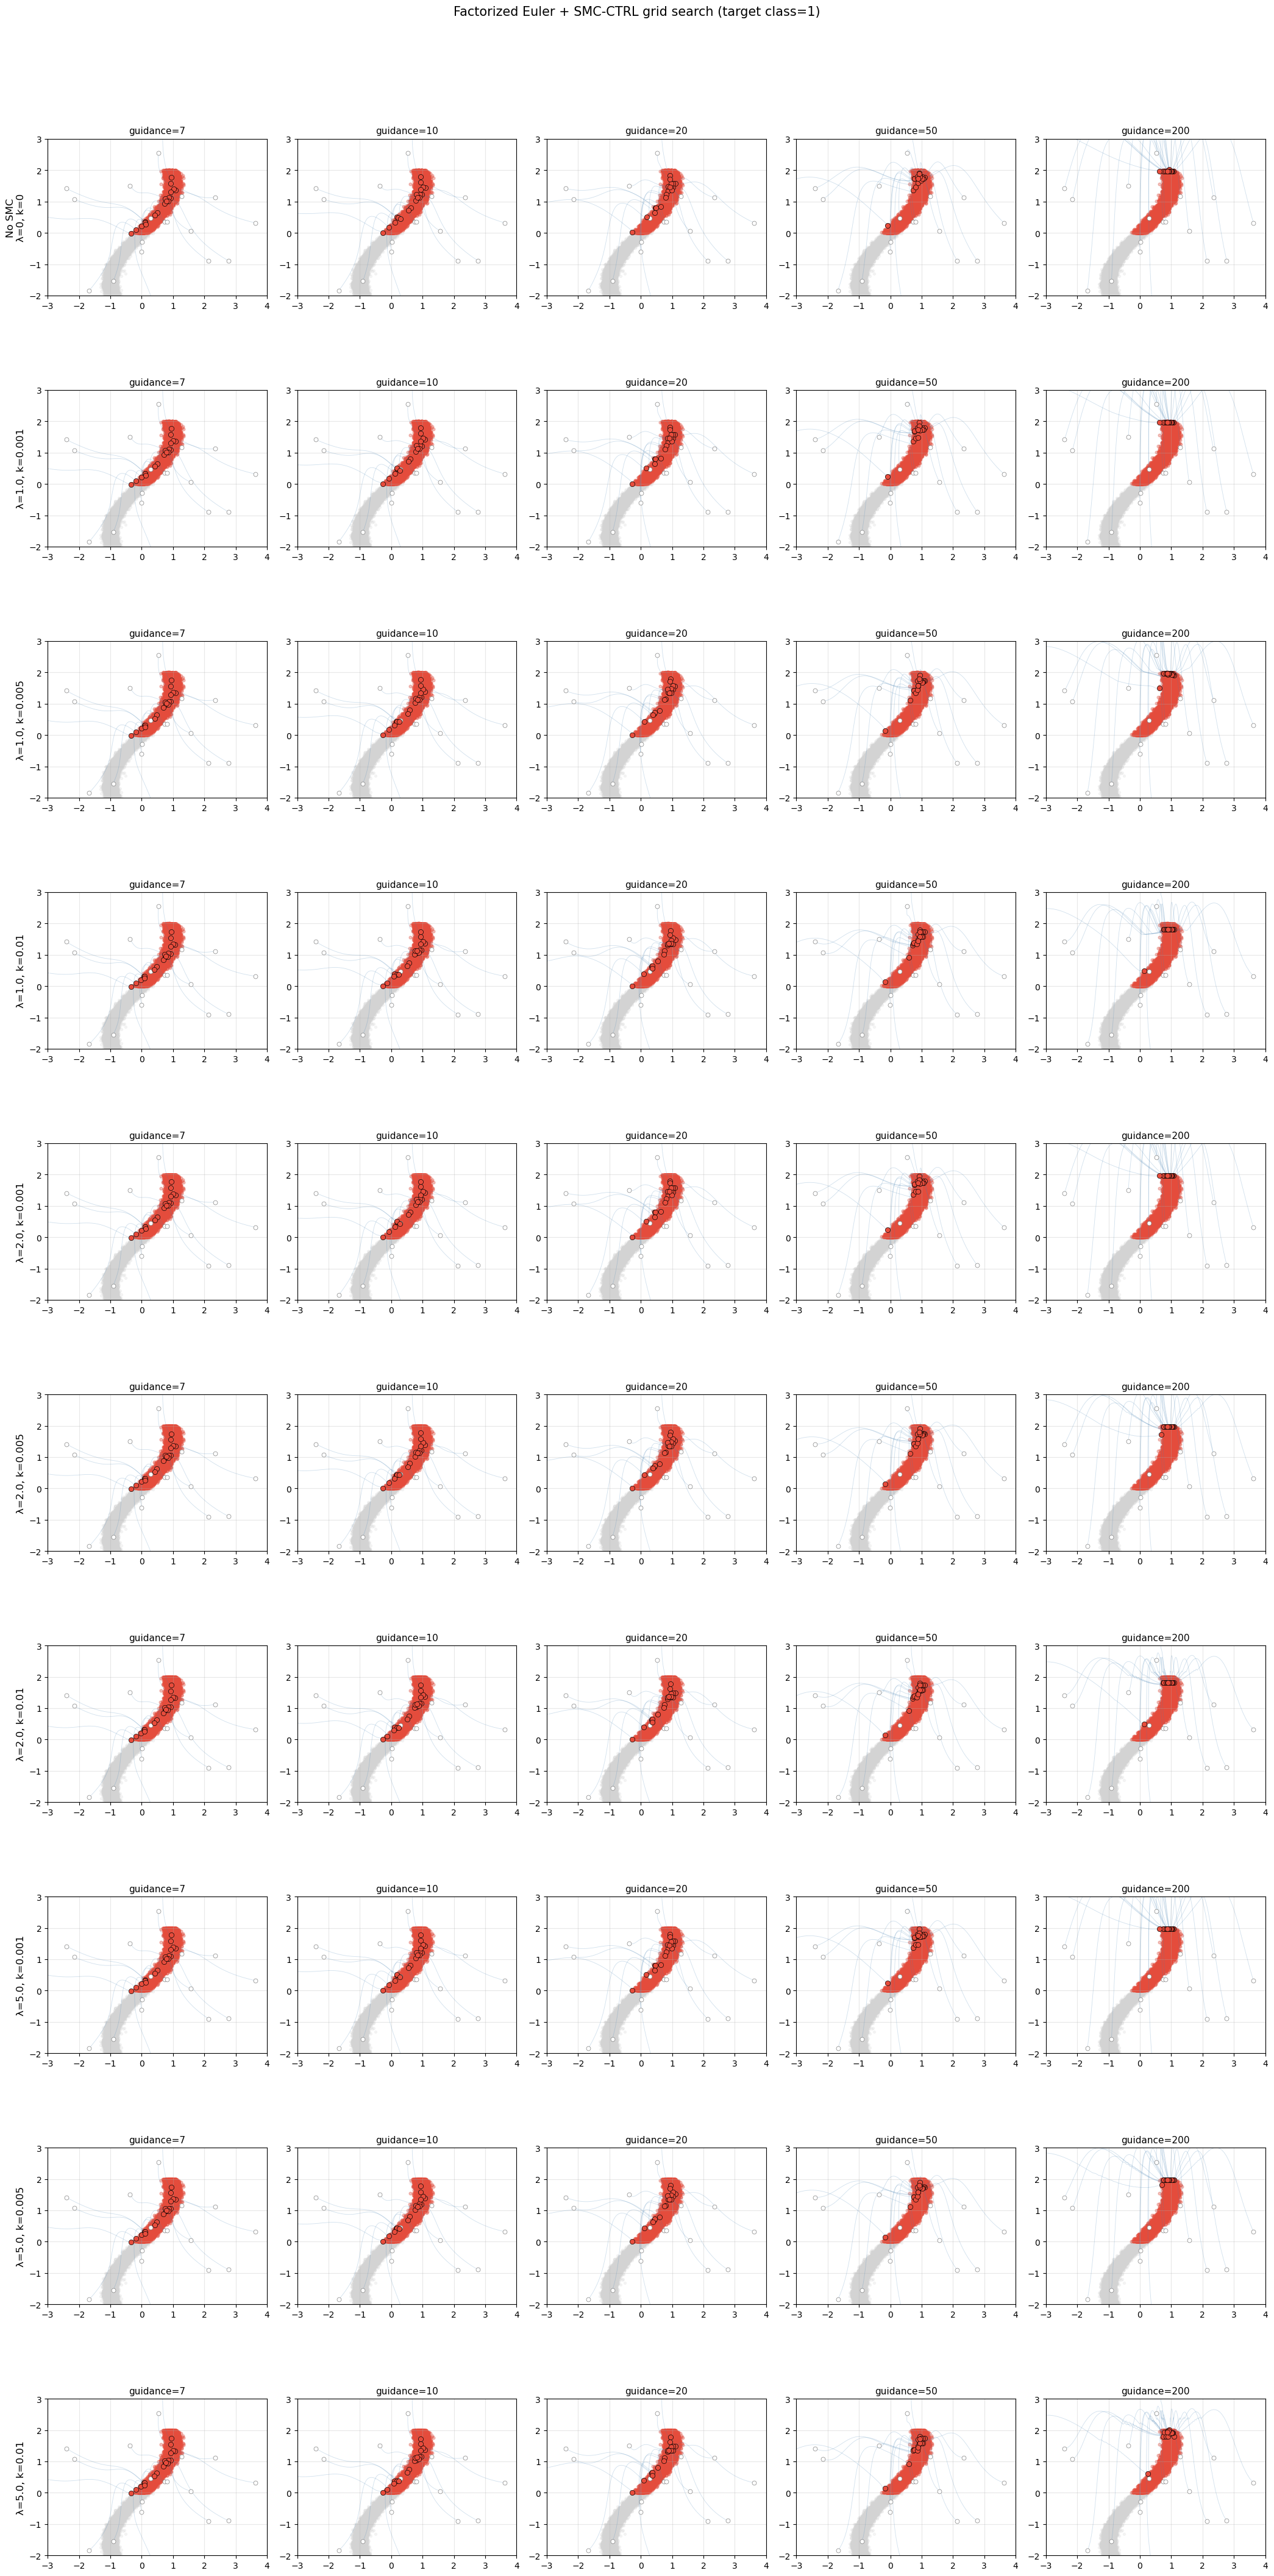

In [14]:
fig, axes = plt.subplots(
    len(smc_configs), len(guidance_scales),
    figsize=(4.2 * len(guidance_scales), 4.2 * len(smc_configs)),
    squeeze=False
)

colors = ['#3498DB', '#E74C3C']
target_np = data_xy.cpu().numpy()
labels_np = (data[:, 2] > 0.5).cpu().numpy()
mask = labels_np == target_class

for i, (smc_lambda, smc_k) in enumerate(smc_configs):
    for j, guidance_scale in enumerate(guidance_scales):
        ax = axes[i, j]
        traj_np = trajectories_grid[(smc_lambda, smc_k, guidance_scale)].cpu().numpy()

        # Background data
        ax.scatter(
            target_np[:, 0], target_np[:, 1],
            c='lightgray', alpha=0.2, s=8
        )

        # Target class
        ax.scatter(
            target_np[mask, 0], target_np[mask, 1],
            c=colors[target_class], alpha=0.3, s=12
        )

        # Trajectories
        for b in range(traj_np.shape[0]):
            ax.plot(
                traj_np[b, :, 0], traj_np[b, :, 1],
                '-', color='steelblue', alpha=0.25, linewidth=0.6
            )

        # Start points
        ax.scatter(
            traj_np[:, 0, 0], traj_np[:, 0, 1],
            c='white', s=25, edgecolors='gray', linewidth=0.5, zorder=5
        )

        # Final points
        ax.scatter(
            traj_np[:, -1, 0], traj_np[:, -1, 1],
            c=colors[target_class], s=35, edgecolors='black', linewidth=0.5, zorder=6
        )

        ax.set_title(f'guidance={guidance_scale}', fontsize=11)
        ax.set_xlim(-3, 4)
        ax.set_ylim(-2, 3)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

        if j == 0:
            if smc_lambda == 0.0 and smc_k == 0.0:
                ax.set_ylabel('No SMC\nλ=0, k=0', fontsize=12)
            else:
                ax.set_ylabel(f'λ={smc_lambda}, k={smc_k}', fontsize=12)

fig.suptitle(
    f'Factorized Euler + SMC-CTRL grid search (target class={target_class})',
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()
